# Modelo 1 y 2

In [ ]:
!gdown https://drive.google.com/uc?id=1mE98-fm4L8Gu3ImxJbo7ndtvEsDx7vEe

Downloading...
From: https://drive.google.com/uc?id=1mE98-fm4L8Gu3ImxJbo7ndtvEsDx7vEe
To: /content/dataset_task.npy
100% 8.07M/8.07M [00:00<00:00, 261MB/s]


In [ ]:
!gdown https://drive.google.com/uc?id=1Ko0yv41fYO8NZBo2_4g2oLq5Hw3L04sw

Downloading...
From: https://drive.google.com/uc?id=1Ko0yv41fYO8NZBo2_4g2oLq5Hw3L04sw
To: /content/babbling_data_variable.npy
100% 24.2M/24.2M [00:00<00:00, 180MB/s]


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import joblib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [ ]:
# Hiperparámetros

WINDOW_SIZE = 4
BATCH_SIZE = 512       # Mitad Task (256), Mitad Babbling (256)
ITERATIONS = 100000
HIDDEN_DIM = 128       # Tamaño de la LSTM y capas densas
LEARNING_RATE = 0.001
MIN_LR = 0.0001
LR_DECAY = 0.92        # Decaimiento del 8% (1 - 0.08)
DECAY_STEPS = 500
EVAL_FREQ = 500        # Frecuencia para hacer el "examen sorpresa" de validación
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Iniciando en dispositivo: {DEVICE}")

Iniciando en dispositivo: cuda


In [ ]:
# Normalización de los datos
try:
    babbling_np = np.load('babbling_data_variable.npy')
    task_np = np.load('dataset_task.npy')
except FileNotFoundError:
    print("No se encontraron los .npy, creando datos falsos para prueba...")
    babbling_np = np.random.rand(409, 400, 37)
    task_np = np.random.rand(50, 1090, 37)

train_split = 0.7
idx_babbling = int(len(babbling_np) * train_split)
idx_task = int(len(task_np) * train_split)

# Partición de Entrenamiento y Validación
babbling_train = babbling_np[:idx_babbling]
babbling_val = babbling_np[idx_babbling:]

task_train = task_np[:idx_task]
task_val = task_np[idx_task:]

# Aplanar, entrenar scaler (SOLO CON TRAIN) y transformar
b_train_flat = babbling_train.reshape(-1, 37)
t_train_flat = task_train.reshape(-1, 37)
train_combinado_flat = np.vstack((b_train_flat, t_train_flat))

scaler = MinMaxScaler(feature_range=(-1, 1), clip=True)
scaler.fit(train_combinado_flat)
joblib.dump(scaler, 'traductor_escalas_mantis.pkl')

# Escalado de Train
b_train_scaled = scaler.transform(b_train_flat).reshape(babbling_train.shape)
t_train_scaled = scaler.transform(t_train_flat).reshape(task_train.shape)

# Escalado de Validación (Justo la pieza que mencionaste)
b_val_scaled = scaler.transform(babbling_val.reshape(-1, 37)).reshape(babbling_val.shape)
t_val_scaled = scaler.transform(task_val.reshape(-1, 37)).reshape(task_val.shape)

In [ ]:
# Creación de sliding window y dataloaders
def create_windows(data, window_size):
    """Convierte secuencias enteras en ventanitas de tamaño fijo"""
    windows_x, windows_y = [], []
    for ep in data:
        for i in range(len(ep) - window_size):
            windows_x.append(ep[i : i + window_size])
            windows_y.append(ep[i + 1 : i + window_size + 1])
    return np.array(windows_x, dtype=np.float32), np.array(windows_y, dtype=np.float32)

print("Cortando tensores en Sliding Windows")
# Data de Train
b_x, b_y = create_windows(b_train_scaled, WINDOW_SIZE)
t_x, t_y = create_windows(t_train_scaled, WINDOW_SIZE)
# Data de Val
b_val_x, b_val_y = create_windows(b_val_scaled, WINDOW_SIZE)
t_val_x, t_val_y = create_windows(t_val_scaled, WINDOW_SIZE)

class LfDDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

# Loaders de Entrenamiento
babbling_loader = DataLoader(LfDDataset(b_x, b_y), batch_size=BATCH_SIZE//2, shuffle=True, drop_last=True)
task_loader = DataLoader(LfDDataset(t_x, t_y), batch_size=BATCH_SIZE//2, shuffle=True, drop_last=True)

# Loaders de Validación (Shuffle=False porque el orden da igual en validación)
val_babbling_loader = DataLoader(LfDDataset(b_val_x, b_val_y), batch_size=BATCH_SIZE//2, shuffle=False, drop_last=True)
val_task_loader = DataLoader(LfDDataset(t_val_x, t_val_y), batch_size=BATCH_SIZE//2, shuffle=False, drop_last=True)


Cortando tensores en Sliding Windows


In [ ]:
# Arquitectura de la red estocastica
class MantisPredictiveRNN(nn.Module):
    def __init__(self, input_dim=37, hidden_dim=128, goal_dim=19):
        super(MantisPredictiveRNN, self).__init__()

        # Capa Compartida
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

        # Capas Exclusivas para Task (Aquí concatenaremos el Goal Vector)
        self.task_dense = nn.Sequential(
            nn.Linear(hidden_dim + goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Capa Final Compartida (Predice Media y Log-Varianza)
        self.final_dense = nn.Linear(hidden_dim, input_dim * 2)

    def forward(self, x_task, x_babble, goal_vector):
        # 1. Unimos todo para pasar por la LSTM y aprender propiocepción general
        x_all = torch.cat([x_task, x_babble], dim=0)
        lstm_out, _ = self.lstm(x_all)

        # 2. Separamos las salidas de la LSTM
        out_task, out_babble = torch.split(lstm_out, [x_task.size(0), x_babble.size(0)], dim=0)

        # 3. Flujo TASK: Concatenar con Goal Vector y pasar por densas
        task_merged = torch.cat([out_task, goal_vector], dim=-1)
        task_features = self.task_dense(task_merged)

        # 4. Flujo BABBLING: El famoso BYPASS
        babble_features = out_babble

        # 5. Reunimos ambos flujos y pasamos por la capa final
        features_all = torch.cat([task_features, babble_features], dim=0)
        final_out = self.final_dense(features_all)

        # Dividimos en Mu (predicción) y Log_Var (incertidumbre)
        mu, log_var = torch.chunk(final_out, chunks=2, dim=-1)
        return mu, log_var

In [ ]:
# Funciones de périda y evaluación
def stochastic_nll_loss(mu, log_var, target):
    var = torch.exp(log_var)
    loss = 0.5 * (np.log(2 * np.pi) + log_var + ((target - mu) ** 2) / var)
    return loss.mean()

def evaluar_modelo(model, val_t_loader, val_b_loader, goal_tensor):
    model.eval() # Modo evaluación
    val_loss_total = 0.0
    batches = 0

    with torch.no_grad(): # No calcular gradientes (ahorra memoria y evita aprender)
        for (x_t, y_t), (x_b, y_b) in zip(val_t_loader, val_b_loader):
            x_t, y_t = x_t.to(DEVICE), y_t.to(DEVICE)
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            y_target_all = torch.cat([y_t, y_b], dim=0)

            mu, log_var = model(x_t, x_b, goal_tensor)
            loss = stochastic_nll_loss(mu, log_var, y_target_all)

            val_loss_total += loss.item()
            batches += 1

    model.train() # Regresar a modo entrenamiento
    return val_loss_total / batches if batches > 0 else 0

In [ ]:
# Entrenamiento

model = MantisPredictiveRNN().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Crear el GOAL VECTOR Ideal (Sensor central = 1, resto = 0)
base_goal = [1.0] + [0.0] * 18
goal_tensor = torch.tensor(base_goal, dtype=torch.float32).view(1, 1, 19)
goal_tensor = goal_tensor.repeat(BATCH_SIZE//2, WINDOW_SIZE, 1).to(DEVICE)

def get_infinite_iter(dataloader):
    while True:
        for batch in dataloader:
            yield batch

task_iter = get_infinite_iter(task_loader)
babble_iter = get_infinite_iter(babbling_loader)

train_loss_history = []
val_loss_history = []
val_steps = []
best_val_loss = float('inf')

pbar = tqdm(range(1, ITERATIONS + 1), desc="Entrenando Red Estocástica")

print("\n==Iniciando Entrenamiento==\n")
for step in pbar:
    # Forward pass
    x_t, y_t = next(task_iter)
    x_b, y_b = next(babble_iter)

    x_t, y_t = x_t.to(DEVICE), y_t.to(DEVICE)
    x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
    y_target_all = torch.cat([y_t, y_b], dim=0)

    optimizer.zero_grad()
    mu, log_var = model(x_t, x_b, goal_tensor)
    loss = stochastic_nll_loss(mu, log_var, y_target_all)

    # Backward pass
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    train_loss_history.append(loss.item())

    # PRUEBA SORPRESA (Validación y Early Stopping)
    if step % EVAL_FREQ == 0:
        val_loss = evaluar_modelo(model, val_task_loader, val_babbling_loader, goal_tensor)
        val_loss_history.append(val_loss)
        val_steps.append(step)

        # Guardar el modelo más inteligente hasta el momento
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'mantis_lfd_mejor_modelo.pth')

        # Decaimiento del Learning Rate (solo cuando evaluamos)
        for param_group in optimizer.param_groups:
            param_group['lr'] = max(param_group['lr'] * LR_DECAY, MIN_LR)

        pbar.set_postfix({'Train': f"{loss.item():.4f}", 'Val': f"{val_loss:.4f}", 'LR': f"{optimizer.param_groups[0]['lr']:.5f}"})
    elif step % 100 == 0:
        # Actualización visual en la consola
        pbar.set_postfix({'Train': f"{loss.item():.4f}", 'LR': f"{optimizer.param_groups[0]['lr']:.5f}"})

# Guardar el modelo de la última iteración por si acaso
torch.save(model.state_dict(), 'mantis_lfd_ultima_iter.pth')
print("Entrenamiento Finalizado. Mejor modelo guardado como 'mantis_lfd_mejor_modelo.pth'")

Entrenando Red Estocástica:   0%|          | 0/100000 [00:00<?, ?it/s]


==Iniciando Entrenamiento==

Entrenamiento Finalizado. Mejor modelo guardado como 'mantis_lfd_mejor_modelo.pth'


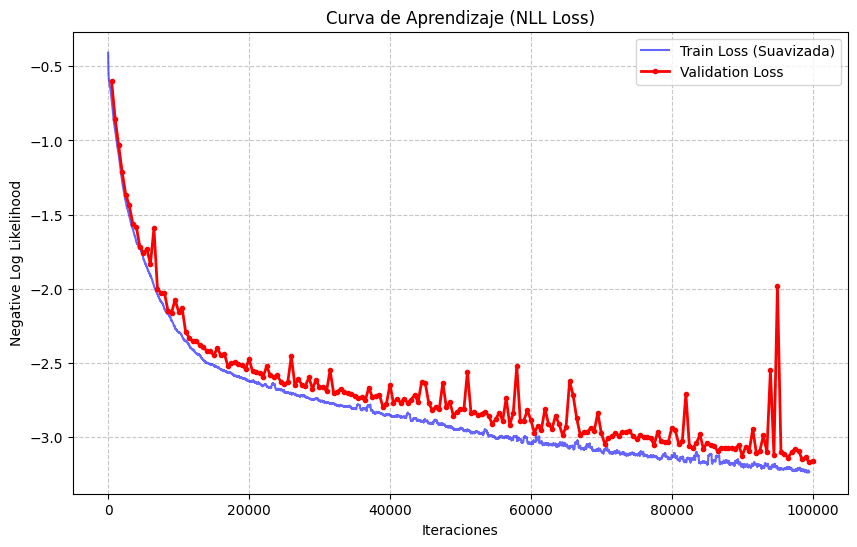

In [ ]:
# Ploteos
plt.figure(figsize=(10,6))
# Suavizado del Train Loss
smoothed_train = np.convolve(train_loss_history, np.ones(500)/500, mode='valid')
plt.plot(smoothed_train, color='blue', alpha=0.6, label='Train Loss (Suavizada)')

# Gráfica del Validation Loss (Se mide cada EVAL_FREQ pasos)
plt.plot(val_steps, val_loss_history, color='red', marker='o', markersize=3, linewidth=2, label='Validation Loss')

plt.title('Curva de Aprendizaje (NLL Loss)')
plt.xlabel('Iteraciones')
plt.ylabel('Negative Log Likelihood')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Modelo 3

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import joblib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [ ]:
# Hiperparámetros
WINDOW_SIZE = 20
BATCH_SIZE = 1024      # Mitad Task (256), Mitad Babbling (256)
ITERATIONS = 100000
HIDDEN_DIM = 256       # Tamaño de la LSTM y capas densas
LEARNING_RATE = 0.001
MIN_LR = 0.0001
#################################################################################################comente esos dos y agrege el factor y la paciencia
#LR_DECAY = 0.92        # Decaimiento del 8% (1 - 0.08)
#DECAY_STEPS = 500
FACTOR = 0.5           # Multiplicador (Ej. reduce a la mitad el LR si se estanca)
PATIENCE = 4           # Número de evaluaciones (EVAL_FREQ) a esperar sin mejoras
############################################################################################################################################################
EVAL_FREQ = 750        # Frecuencia para hacer el "examen sorpresa" de validación
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Iniciando en dispositivo: {DEVICE}")

In [ ]:
# Normalización de datos
# Simulación de carga (Reemplaza con tus archivos reales)
try:
    babbling_np = np.load('babbling_data_variable.npy')
    task_np = np.load('dataset_task.npy')
except FileNotFoundError:
    print("No se encontraron los .npy, creando datos falsos para prueba")
    babbling_np = np.random.rand(409, 400, 37)
    task_np = np.random.rand(50, 1090, 37)

train_split = 0.7
idx_babbling = int(len(babbling_np) * train_split)
idx_task = int(len(task_np) * train_split)

# Partición de Entrenamiento y Validación
babbling_train = babbling_np[:idx_babbling]
babbling_val = babbling_np[idx_babbling:]

task_train = task_np[:idx_task]
task_val = task_np[idx_task:]

# Aplanar, entrenar scaler (SOLO CON TRAIN) y transformar
b_train_flat = babbling_train.reshape(-1, 37)
t_train_flat = task_train.reshape(-1, 37)
train_combinado_flat = np.vstack((b_train_flat, t_train_flat))

scaler = MinMaxScaler(feature_range=(-1, 1), clip=True)
scaler.fit(train_combinado_flat)
joblib.dump(scaler, 'traductor_escalas_mantis.pkl')

# Escalado de Train
b_train_scaled = scaler.transform(b_train_flat).reshape(babbling_train.shape)
t_train_scaled = scaler.transform(t_train_flat).reshape(task_train.shape)

# Escalado de Validación (Justo la pieza que mencionaste)
b_val_scaled = scaler.transform(babbling_val.reshape(-1, 37)).reshape(babbling_val.shape)
t_val_scaled = scaler.transform(task_val.reshape(-1, 37)).reshape(task_val.shape)

In [ ]:
# Sliding windows y dataloaders
def create_windows(data, window_size):
    """Convierte secuencias enteras en ventanitas de tamaño fijo"""
    windows_x, windows_y = [], []
    for ep in data:
        for i in range(len(ep) - window_size):
            windows_x.append(ep[i : i + window_size])
            windows_y.append(ep[i + 1 : i + window_size + 1])
    return np.array(windows_x, dtype=np.float32), np.array(windows_y, dtype=np.float32)

print("\n✂️ Cortando tensores en Sliding Windows...")
# Data de Train
b_x, b_y = create_windows(b_train_scaled, WINDOW_SIZE)
t_x, t_y = create_windows(t_train_scaled, WINDOW_SIZE)
# Data de Val
b_val_x, b_val_y = create_windows(b_val_scaled, WINDOW_SIZE)
t_val_x, t_val_y = create_windows(t_val_scaled, WINDOW_SIZE)

class LfDDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

# Loaders de Entrenamiento
babbling_loader = DataLoader(LfDDataset(b_x, b_y), batch_size=BATCH_SIZE//2, shuffle=True, drop_last=True)
task_loader = DataLoader(LfDDataset(t_x, t_y), batch_size=BATCH_SIZE//2, shuffle=True, drop_last=True)

# Loaders de Validación (Shuffle=False porque el orden da igual en validación)
val_babbling_loader = DataLoader(LfDDataset(b_val_x, b_val_y), batch_size=BATCH_SIZE//2, shuffle=False, drop_last=True)
val_task_loader = DataLoader(LfDDataset(t_val_x, t_val_y), batch_size=BATCH_SIZE//2, shuffle=False, drop_last=True)

In [ ]:
# Arquitectura de la red estocástica
class MantisPredictiveRNN(nn.Module):
    def __init__(self, input_dim=37, hidden_dim=128, goal_dim=19):
        super(MantisPredictiveRNN, self).__init__()

        # Capa Compartida
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

        # Capas Exclusivas para Task (Aquí concatenaremos el Goal Vector)
        self.task_dense = nn.Sequential(
            nn.Linear(hidden_dim + goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Capa Final Compartida (Predice Media y Log-Varianza)
        self.final_dense = nn.Linear(hidden_dim, input_dim * 2)

    def forward(self, x_task, x_babble, goal_vector):
        # 1. Unimos todo para pasar por la LSTM y aprender propiocepción general
        x_all = torch.cat([x_task, x_babble], dim=0)
        lstm_out, _ = self.lstm(x_all)

        # 2. Separamos las salidas de la LSTM
        out_task, out_babble = torch.split(lstm_out, [x_task.size(0), x_babble.size(0)], dim=0)

        # 3. Flujo TASK: Concatenar con Goal Vector y pasar por densas
        task_merged = torch.cat([out_task, goal_vector], dim=-1)
        task_features = self.task_dense(task_merged)

        # 4. Flujo BABBLING: El famoso BYPASS
        babble_features = out_babble

        # 5. Reunimos ambos flujos y pasamos por la capa final
        features_all = torch.cat([task_features, babble_features], dim=0)
        final_out = self.final_dense(features_all)

        # Dividimos en Mu (predicción) y Log_Var (incertidumbre)
        mu, log_var = torch.chunk(final_out, chunks=2, dim=-1)
        return mu, log_var

In [ ]:
# Funciones de pérdida y evaluación
def stochastic_nll_loss(mu, log_var, target):
    var = torch.exp(log_var)
    loss = 0.5 * (np.log(2 * np.pi) + log_var + ((target - mu) ** 2) / var)
    return loss.mean()

def evaluar_modelo(model, val_t_loader, val_b_loader, goal_tensor):
    model.eval() # Modo evaluación
    val_loss_total = 0.0
    batches = 0

    with torch.no_grad(): # No calcular gradientes (ahorra memoria y evita aprender)
        for (x_t, y_t), (x_b, y_b) in zip(val_t_loader, val_b_loader):
            x_t, y_t = x_t.to(DEVICE), y_t.to(DEVICE)
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            y_target_all = torch.cat([y_t, y_b], dim=0)

            mu, log_var = model(x_t, x_b, goal_tensor)
            loss = stochastic_nll_loss(mu, log_var, y_target_all)

            val_loss_total += loss.item()
            batches += 1

    model.train() # Regresar a modo entrenamiento
    return val_loss_total / batches if batches > 0 else 0

In [ ]:
# Entrenamiento
model = MantisPredictiveRNN().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
################################################################################### solo lo agrege el scheduler
# INICIALIZACIÓN DEL SCHEDULER DINÁMICO
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         # Queremos minimizar el val_loss
    factor=FACTOR,
    patience=PATIENCE,
    min_lr=MIN_LR
)
#####################################################################################################################################################
# Crear el GOAL VECTOR Ideal (Sensor central = 1, resto = 0)
base_goal = [1.0] + [0.0] * 18
goal_tensor = torch.tensor(base_goal, dtype=torch.float32).view(1, 1, 19)
goal_tensor = goal_tensor.repeat(BATCH_SIZE//2, WINDOW_SIZE, 1).to(DEVICE)

def get_infinite_iter(dataloader):
    while True:
        for batch in dataloader:
            yield batch

task_iter = get_infinite_iter(task_loader)
babble_iter = get_infinite_iter(babbling_loader)

train_loss_history = []
val_loss_history = []
val_steps = []
best_val_loss = float('inf')

pbar = tqdm(range(1, ITERATIONS + 1), desc="Entrenando Red Estocástica")

print("\n==Iniciando Entrenamiento==n")
for step in pbar:
    # Forward pass
    x_t, y_t = next(task_iter)
    x_b, y_b = next(babble_iter)

    x_t, y_t = x_t.to(DEVICE), y_t.to(DEVICE)
    x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
    y_target_all = torch.cat([y_t, y_b], dim=0)

    optimizer.zero_grad()
    mu, log_var = model(x_t, x_b, goal_tensor)
    loss = stochastic_nll_loss(mu, log_var, y_target_all)

    # Backward pass
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    train_loss_history.append(loss.item())

    #  PRUEBA SORPRESA (Validación y Early Stopping)
    if step % EVAL_FREQ == 0:
        val_loss = evaluar_modelo(model, val_task_loader, val_babbling_loader, goal_tensor)
        val_loss_history.append(val_loss)
        val_steps.append(step)

        # Guardar el modelo más inteligente hasta el momento
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'mantis_lfd_mejor_modelo.pth')
#############################################################################################################comente lo del for y agrege lo del scheduler
        # Decaimiento del Learning Rate (solo cuando evaluamos)
        #for param_group in optimizer.param_groups:
            #param_group['lr'] = max(param_group['lr'] * LR_DECAY, MIN_LR)

        # El scheduler evalúa la pérdida de validación y decide si ajustar el LR
        scheduler.step(val_loss)
#####################################################################################################################################################################
        pbar.set_postfix({'Train': f"{loss.item():.4f}", 'Val': f"{val_loss:.4f}", 'LR': f"{optimizer.param_groups[0]['lr']:.5f}"})
    elif step % 100 == 0:
        # Actualización visual en la consola
        pbar.set_postfix({'Train': f"{loss.item():.4f}", 'LR': f"{optimizer.param_groups[0]['lr']:.5f}"})

# Guardar el modelo de la última iteración por si acaso
torch.save(model.state_dict(), 'mantis_lfd_ultima_iter.pth')
print("Entrenamiento Finalizado. Mejor modelo guardado como 'mantis_lfd_mejor_modelo.pth'")

In [ ]:
# Ploteos
plt.figure(figsize=(10,6))
# Suavizado del Train Loss
smoothed_train = np.convolve(train_loss_history, np.ones(500)/500, mode='valid')
plt.plot(smoothed_train, color='blue', alpha=0.6, label='Train Loss (Suavizada)')

# Gráfica del Validation Loss (Se mide cada EVAL_FREQ pasos)
plt.plot(val_steps, val_loss_history, color='red', marker='o', markersize=3, linewidth=2, label='Validation Loss')

plt.title('Curva de Aprendizaje (NLL Loss)')
plt.xlabel('Iteraciones')
plt.ylabel('Negative Log Likelihood')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()